In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

**Data Loading**

In [6]:
path = r"C:\Users\admin\Downloads\archive (5)\Student_Performance.csv"
df = pd.read_csv(path)
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


**Data Pre - Processing**

In [8]:
#identify the nulls 
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [13]:
#check for duplicates
df.duplicated().sum()
#remove duplicates
df = df.drop_duplicates()

In [14]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [15]:
#Hourse studied column 
print(df['Hours Studied'].dtype)        
print(df['Hours Studied'].unique()[:10])  
print(df['Hours Studied'].describe()) 

int64
[7 4 8 5 3 6 2 1 9]
count    9873.000000
mean        4.992100
std         2.589081
min         1.000000
25%         3.000000
50%         5.000000
75%         7.000000
max         9.000000
Name: Hours Studied, dtype: float64


In [16]:
#drop null or where houre is 0
df = df[df['Hours Studied'].notnull()]
df = df[df['Hours Studied'] >= 0]

In [17]:
#convert column to integer
df['Hours Studied'] = df['Hours Studied'].round().astype(int)

In [18]:
#Previous Scores column
#drop null
df = df[df['Previous Scores'].notnull()]
#remove scores greater than 100
df = df[(df['Previous Scores'] >= 0) & (df['Previous Scores'] <= 100)]

In [19]:
print(df['Previous Scores'].isnull().sum())     
print(df['Previous Scores'].dtype)              
print(df['Previous Scores'].describe())  

0
int64
count    9873.000000
mean       69.441102
std        17.325601
min        40.000000
25%        54.000000
50%        69.000000
75%        85.000000
max        99.000000
Name: Previous Scores, dtype: float64


In [20]:
#Extracurricular Activities column 
print(df['Extracurricular Activities'].dtype)         
print(df['Extracurricular Activities'].unique())      
print(df['Extracurricular Activities'].value_counts()) 

object
['Yes' 'No']
Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64


In [48]:
df["Extracurricular Activities"].unique()

array(['Yes', 'No'], dtype=object)

In [52]:
# Convert "Yes"/"No" to 1/0
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

In [21]:
#Sleep Hours column 
print(df['Sleep Hours'].dtype)         
print(df['Sleep Hours'].unique())      
print(df['Sleep Hours'].value_counts()) 

int64
[9 4 7 5 8 6]
Sleep Hours
8    1784
7    1653
6    1645
9    1606
4    1605
5    1580
Name: count, dtype: int64


In [23]:
#Performance Index column 
print(df['Performance Index'].dtype)
print(df['Performance Index'].describe())
print(df['Performance Index'].unique()[:10])

float64
count    9873.000000
mean       55.216651
std        19.208570
min        10.000000
25%        40.000000
50%        55.000000
75%        70.000000
max       100.000000
Name: Performance Index, dtype: float64
[91. 65. 45. 36. 66. 61. 63. 42. 69. 84.]


In [22]:
#Sample Question Papers Practiced column
print(df['Sample Question Papers Practiced'].dtype)
print(df['Sample Question Papers Practiced'].describe())
print(df['Sample Question Papers Practiced'].unique()[:10])

int64
count    9873.000000
mean        4.583004
std         2.867202
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max         9.000000
Name: Sample Question Papers Practiced, dtype: float64
[1 2 5 6 0 8 3 4 9 7]


In [36]:
df[['Hours Studied', 'Performance Index']].dropna(inplace = True)

C:\Users\admin\AppData\Local\Temp\ipykernel_15692\330671153.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Hours Studied', 'Performance Index']].dropna(inplace = True)


In [24]:
#convert to integer 
df['Performance Index'] = df['Performance Index'].round().astype(int)

**Plotting**

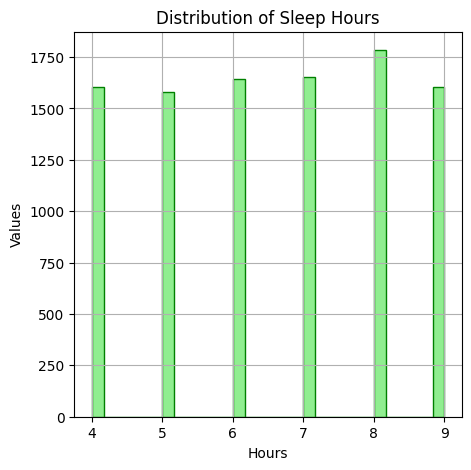

In [68]:
#Sleep hourse plot
plt.figure(figsize=(5,5))
plt.hist(df['Sleep Hours'], bins=30, color='lightgreen', edgecolor='green',)
plt.title('Distribution of Sleep Hours')
plt.xlabel('Hours')
plt.ylabel('Values')
plt.grid(True)
plt.show()

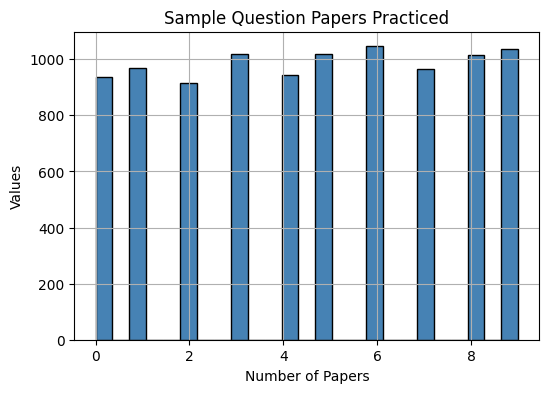

In [62]:
#Sample Question Papers Practicedplot
plt.figure(figsize=(6,4))
plt.hist(df['Sample Question Papers Practiced'], bins=25, color='steelblue', edgecolor='black')
plt.title('Sample Question Papers Practiced')
plt.xlabel('Number of Papers')
plt.ylabel('Values')
plt.grid(True)
plt.show()

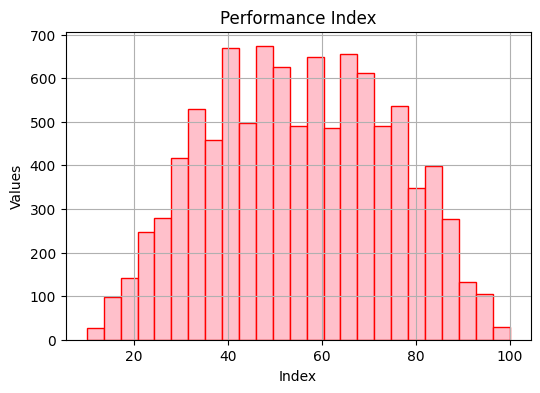

In [69]:
#Performance Index plot
plt.figure(figsize=(6,4))
plt.hist(df['Performance Index'], bins=25, color='pink', edgecolor='red')
plt.title('Performance Index')
plt.xlabel('Index')
plt.ylabel('Values')
plt.grid(True)
plt.show()

**Machine Learning**

In [70]:
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Linear Regression**

In [71]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# Evaluate the model (metrics explained)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Linear Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

--- Linear Regression Results ---
Mean Absolute Error (MAE): 1.65
Mean Squared Error (MSE): 4.31
Root Mean Squared Error (RMSE): 2.08
R-squared (R2): 0.99


**Polynomial Regression**

In [56]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)
y_pred_poly = poly_model.predict(X_poly_test)
#Evaluate the model (metrics explained)
mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)

print("--- Poly Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

--- Poly Regression Results ---
Mean Absolute Error (MAE): 1.65
Mean Squared Error (MSE): 4.31
Root Mean Squared Error (RMSE): 2.07
R-squared (R2): 0.99


**Lasso Regression**

In [64]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_lasso)
mse = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso)
print("--- Lasso Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

--- Lasso Regression Results ---
Mean Absolute Error (MAE): 1.67
Mean Squared Error (MSE): 4.41
Root Mean Squared Error (RMSE): 2.10
R-squared (R2): 0.99


**Ridge Regression**

In [58]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)
print("--- Ridge Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

--- Ridge Regression Results ---
Mean Absolute Error (MAE): 1.65
Mean Squared Error (MSE): 4.31
Root Mean Squared Error (RMSE): 2.08
R-squared (R2): 0.99


**Decision Tree Regression**

In [59]:
dct = DecisionTreeRegressor(random_state=42)
dct.fit(X_train, y_train)
y_pred_dct = dct.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_dct)
mse = mean_squared_error(y_test, y_pred_dct)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dct)
print("--- DCT Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

--- DCT Regression Results ---
Mean Absolute Error (MAE): 2.41
Mean Squared Error (MSE): 9.21
Root Mean Squared Error (RMSE): 3.03
R-squared (R2): 0.98


**Random Forest Regressor**

In [60]:
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)
y_pred_rfr = rfr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_rfr)
mse = mean_squared_error(y_test, y_pred_rfr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rfr)
print("--- Random Forest Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

--- Random Forest Regression Results ---
Mean Absolute Error (MAE): 1.90
Mean Squared Error (MSE): 5.63
Root Mean Squared Error (RMSE): 2.37
R-squared (R2): 0.98


**SVM Regressor**

In [61]:
svr = SVR()
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_svr)
print("--- SVMR Regression Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

--- SVMR Regression Results ---
Mean Absolute Error (MAE): 1.89
Mean Squared Error (MSE): 5.64
Root Mean Squared Error (RMSE): 2.37
R-squared (R2): 0.98


**Regression Results**
- Linear, Polynomial, Ridge, and Lasso Regression have similar good performance.
- R² = 0.99 indicates 99% of the variance, and RMSE (2.07-2.10) indicates almost low average error.
- Polynomial RMSE improved by 0.01 because the data is almost linear.
- Best choice: Linear Regression or Polynomial Regression as they are accurate and consistent.